    https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci

___

```
╔══════════════════════════════════════════════════════════════╗
║       HEART DISEASE PREDICTION — FINAL SUMMARY              ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset        : Cleveland Heart Disease (279 rows)         ║
║  Features       : 13 raw → 18 after One Hot Encoding         ║
║  Target         : condition (0=healthy, 1=disease)           ║
╠══════════════════════════════════════════════════════════════╣
║  MODELS TRAINED                                              ║
║  SVC Linear       → Accuracy 0.86  AUC 0.9394               ║
║  SVC RBF          → Accuracy 0.84  AUC 0.9110               ║
║  SVC Polynomial   → Accuracy 0.82  AUC 0.9316               ║
║  Logistic Reg     → Accuracy 0.86  AUC 0.9445               ║
║  SVC RBF Tuned    → Accuracy 0.86  AUC 0.9419               ║
║  LR Tuned         → Accuracy 0.80  AUC 0.9458  ← SELECTED  ║
╠══════════════════════════════════════════════════════════════╣
║  FINAL MODEL : LR Tuned + Threshold 0.55                    ║
║  AUC            : 0.9458                                     ║
║  Recall         : 0.96  → catches 24/25 sick patients        ║
║  Precision      : 0.75  → 3 of 4 flagged are real disease    ║
║  Accuracy       : 0.84                                       ║
║  Disease missed : 1/25  (4%)                                 ║
║  False alarms   : 8/31  (26%)                                ║
╠══════════════════════════════════════════════════════════════╣
║  WHY LR TUNED OVER SVC?                                     ║
║  SVC RBF Tuned has higher accuracy (0.86) but recall 0.72   ║
║  LR Tuned catches 24/25 sick patients vs SVC catching 18/25 ║
║  In healthcare missing a sick patient is unacceptable        ║
╠══════════════════════════════════════════════════════════════╣
║  THRESHOLD SELECTION                                         ║
║  Default 0.50 recall : 0.96  precision : 0.71               ║
║  Optimal 0.55 recall : 0.96  precision : 0.75  ← selected   ║
║  Youden's J statistic: 0.7665                                ║
╚══════════════════════════════════════════════════════════════╝
""")

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import plotly.express as px
%matplotlib inline

In [59]:
df = pd.read_csv("heart_cleveland_upload.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


``` age       →  age in years                          →  numeric
sex       →  0 = female, 1 = male                  →  binary
cp        →  chest pain type (0,1,2,3)             →  categorical
trestbps  →  resting blood pressure (mm Hg)        →  numeric — outliers likely
chol      →  cholesterol (mg/dl)                    →  numeric — outliers likely
fbs       →  fasting blood sugar > 120 (0/1)        →  binary
restecg   →  resting ECG results (0,1,2)            →  categorical
thalach   →  max heart rate achieved                →  numeric
exang     →  exercise induced angina (0/1)          →  binary
oldpeak   →  ST depression                          →  numeric — skewness likely
slope     →  slope of peak exercise ST (0,1,2)      →  categorical
ca        →  number of major vessels (0-3)           →  numeric
thal      →  thalassemia (0,1,2)                    →  categorical
condition →  TARGET (0 = no disease, 1 = disease)   →  binary

In [60]:
df.shape

(297, 14)

In [61]:
df.columns.to_list()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'condition']

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [63]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [64]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

___
# EDA
___

/tmp/ipykernel_6905/703025405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="condition", data=df, palette=["steelblue", "coral"])


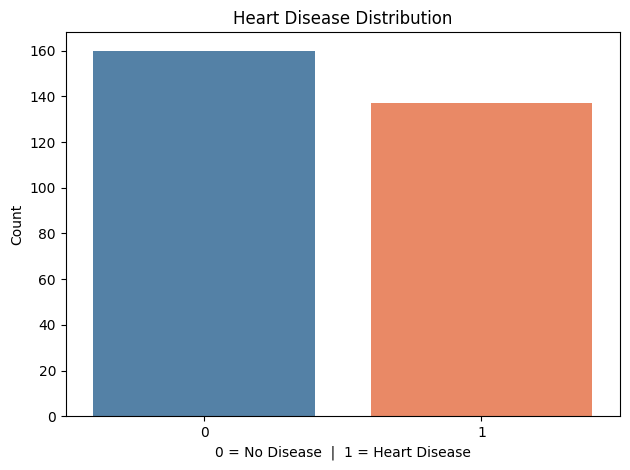

In [65]:
# target distribution
sns.countplot(x="condition", data=df, palette=["steelblue", "coral"])
plt.title("Heart Disease Distribution")
plt.xlabel("0 = No Disease  |  1 = Heart Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

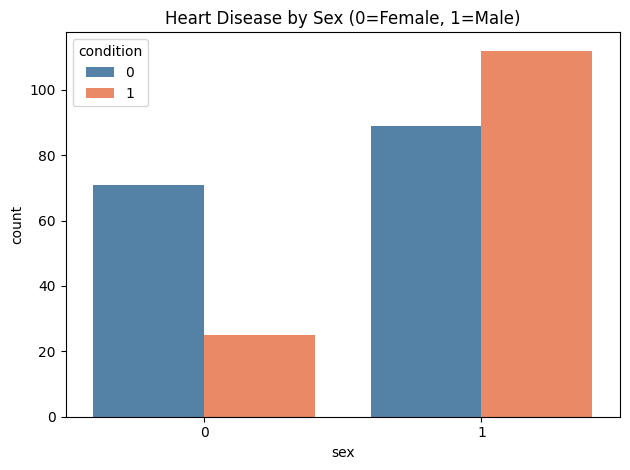

In [66]:
# survival by sex
sns.countplot(x="sex", hue="condition", data=df, palette=["steelblue", "coral"])
plt.title("Heart Disease by Sex (0=Female, 1=Male)")
plt.tight_layout()
plt.show()

``` 
Females have less chances of Heart disease as compared to males

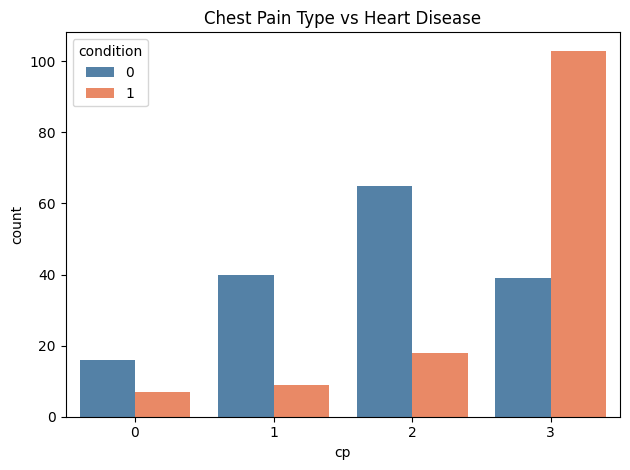

In [67]:
# chest pain type vs condition
sns.countplot(x="cp", hue="condition", data=df, palette=["steelblue", "coral"])
plt.title("Chest Pain Type vs Heart Disease")
plt.tight_layout()
plt.show()

```
cp = 0 (typical angina)   → mostly no disease
cp = 1 (atypical angina)  → mostly no disease
cp = 2 (non-anginal)      → mostly no disease
cp = 3 (asymptomatic)     → MOSTLY HEART DISEASE ← strongest signal

Patients with asymptomatic chest pain (cp=3) have the highest
rate of heart disease — this is a known medical fact
They feel no chest pain but have blocked arteries

chest pain type 3 is linked with heart disease. as there is high count of people with heart disease with chest pain type 3

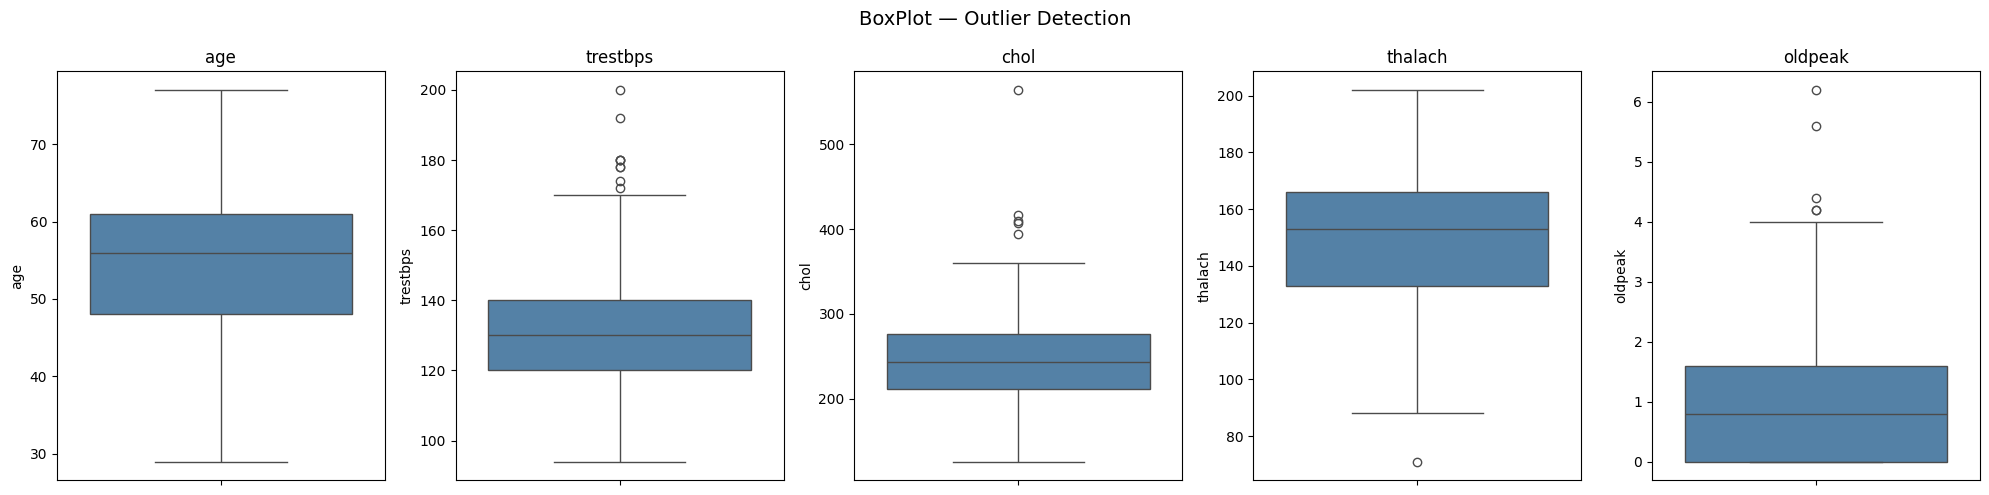

In [68]:
# Boxplots for continuous features — detect outliers visually
# these are the columns where IQR outlier removal matters

continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

plt.suptitle("BoxPlot — Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

# look for dots outside the whiskers — those are outliers

```
age      →  no outliers ✅
trestbps →  several dots above 160 — outliers above upper whisker
chol     →  3-4 dots above 400 — one at 564 is extreme
thalach  →  1-2 dots below 80 — minor outliers
oldpeak  →  3-4 dots above 4.0 — values at 5.0 and 6.2

In [69]:
# check skewness of continuous features
# skewness > 1 or < -1 → highly skewed → may need transformation

for col in continuous_cols:
    skew = df[col].skew()
    print(f"{col:12} → skewness: {skew:.4f}  {'⚠️ skewed' if abs(skew) > 1 else '✅ ok'}")

age          → skewness: -0.2198  ✅ ok
trestbps     → skewness: 0.7001  ✅ ok
chol         → skewness: 1.1181  ⚠️ skewed
thalach      → skewness: -0.5365  ✅ ok
oldpeak      → skewness: 1.2471  ⚠️ skewed


```
 chol     →  1.1181 ⚠️  right skewed — long tail to the right (few very high cholesterol)
oldpeak  →  1.2471 ⚠️  right skewed — most values near 0, few at 4-6

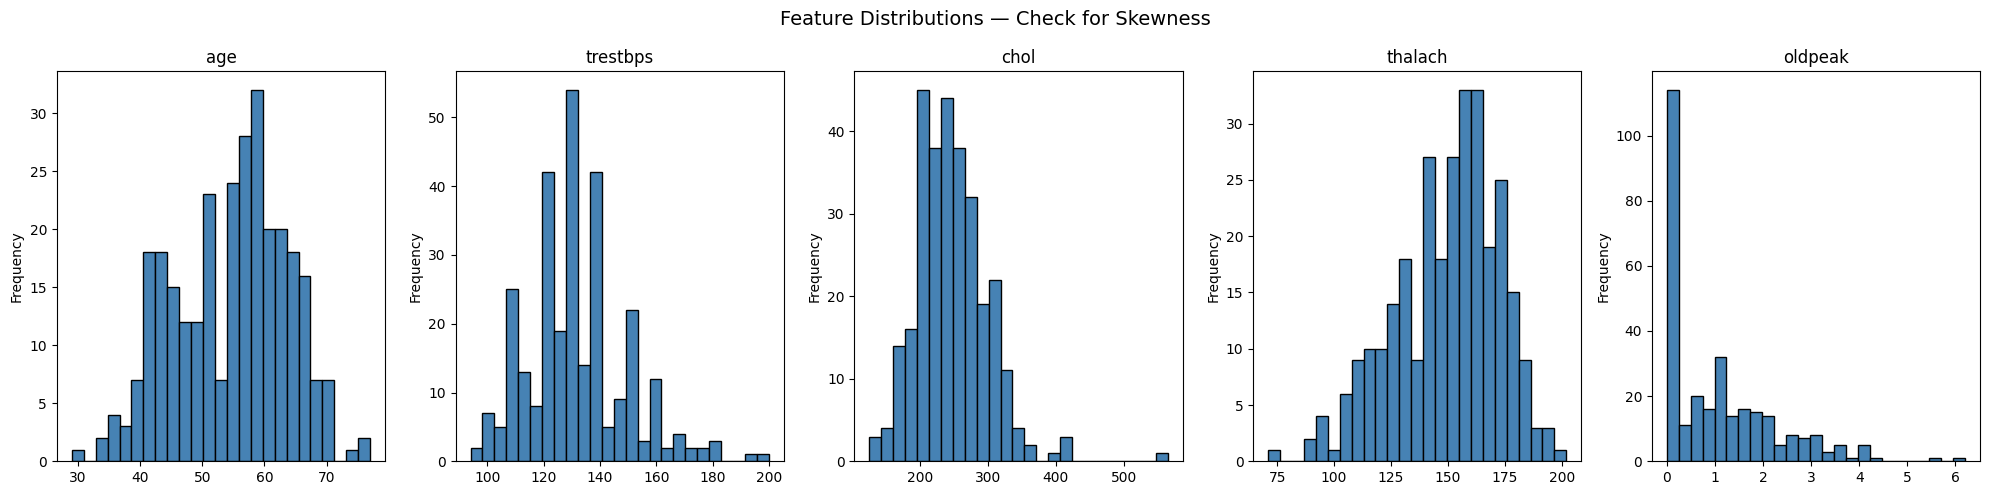

In [70]:
# histogram of each continuous feature
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
# 1 row, 5 columns → creates 5 empty plot boxes
# axes is now a list of 5 plot boxes:
# axes = [box0, box1, box2, box3, box4]

for i, col in enumerate(continuous_cols):
    df[col].plot(kind="hist", bins=25, ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Iteration 1 → i=0, col="age"      → draws boxplot in axes[0] (1st box)
# Iteration 2 → i=1, col="trestbps" → draws boxplot in axes[1] (2nd box)
# Iteration 3 → i=2, col="chol"     → draws boxplot in axes[2] (3rd box)
# Iteration 4 → i=3, col="thalach"  → draws boxplot in axes[3] (4th box)
# Iteration 5 → i=4, col="oldpeak"  → draws boxplot in axes[4] (5th box)

plt.suptitle("Feature Distributions — Check for Skewness", fontsize=14)
plt.tight_layout()
plt.show()

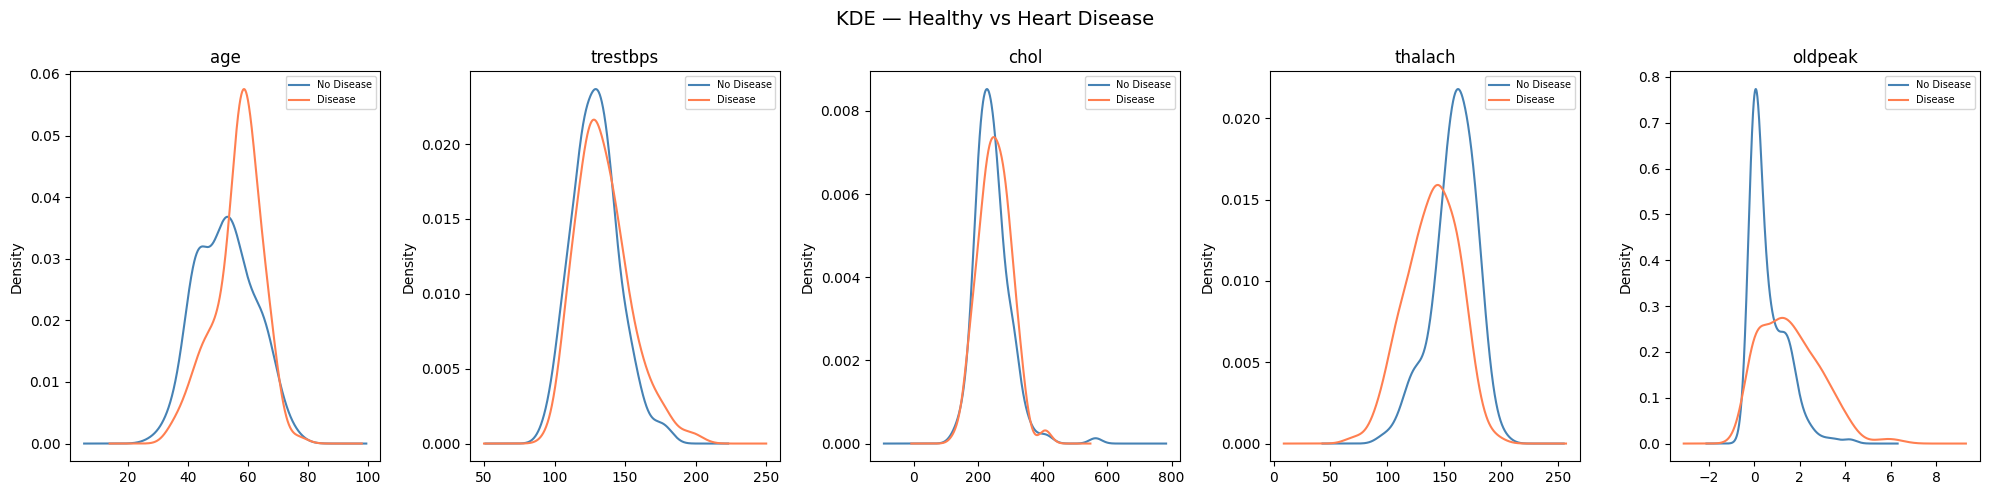

In [71]:
# KDE — compare distribution of sick vs healthy for each feature
# this shows WHERE the two groups differ

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(continuous_cols):
    df[df["condition"] == 0][col].plot(kind="kde", ax=axes[i], color="steelblue", label="No Disease")
    df[df["condition"] == 1][col].plot(kind="kde", ax=axes[i], color="coral", label="Disease")
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle("KDE — Healthy vs Heart Disease", fontsize=14)
plt.tight_layout()
plt.show()

# where the two curves are far apart → that feature separates the classes well
# where curves overlap → that feature does not help much

____
 # Removing Outliers

    above we got outliers  now we'll remove it using IQR
____


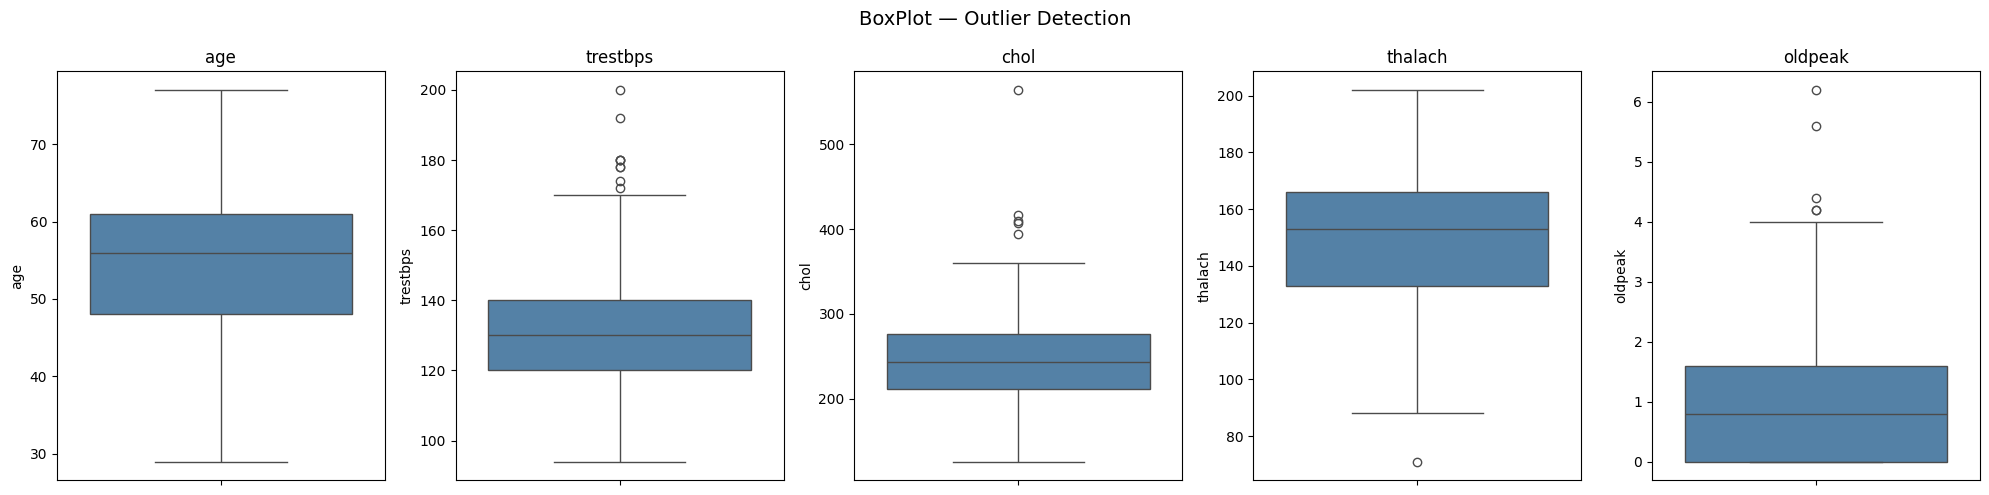

In [72]:
# Boxplots for continuous features — detect outliers visually
# these are the columns where IQR outlier removal matters

continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

plt.suptitle("BoxPlot — Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

# look for dots outside the whiskers — those are outliers


```
age      →  no outliers ✅
trestbps →  several dots above 160 — outliers above upper whisker
chol     →  3-4 dots above 400 — one at 564 is extreme
thalach  →  1-2 dots below 80 — minor outliers
oldpeak  →  3-4 dots above 4.0 — values at 5.0 and 6.2

In [73]:
# work on a copy
df_clean = df.copy()

In [74]:
# IQR method on columns with visible outliers from boxplots
# trestbps, chol, oldpeak

outlier_cols = ["trestbps", "chol", "oldpeak"]

print("Before outlier removal:", df_clean.shape)
print()

for col in outlier_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)

    
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df_clean.shape[0]
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    after = df_clean.shape[0]

    print(f"{col:12} → Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  Lower={lower:.1f}  Upper={upper:.1f}  → removed {before - after} rows")

df_clean.reset_index(drop=True, inplace=True)
print()
print("After outlier removal:", df_clean.shape)

Before outlier removal: (297, 14)

trestbps     → Q1=120.0  Q3=140.0  IQR=20.0  Lower=90.0  Upper=170.0  → removed 9 rows
chol         → Q1=211.0  Q3=275.0  IQR=64.0  Lower=115.0  Upper=371.0  → removed 5 rows
oldpeak      → Q1=0.0  Q3=1.6  IQR=1.6  Lower=-2.4  Upper=4.0  → removed 4 rows

After outlier removal: (279, 14)


## checking skewness again after removinf Outliers

In [75]:
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("Skewness after outlier removal:")
print()
for col in continuous_cols:
    skew = df_clean[col].skew()
    print(f"{col:12} → skewness: {skew:.4f}  {'⚠️ still skewed' if abs(skew) > 1 else '✅ ok'}")

Skewness after outlier removal:

age          → skewness: -0.1642  ✅ ok
trestbps     → skewness: 0.2668  ✅ ok
chol         → skewness: 0.1756  ✅ ok
thalach      → skewness: -0.5646  ✅ ok
oldpeak      → skewness: 0.9048  ✅ ok


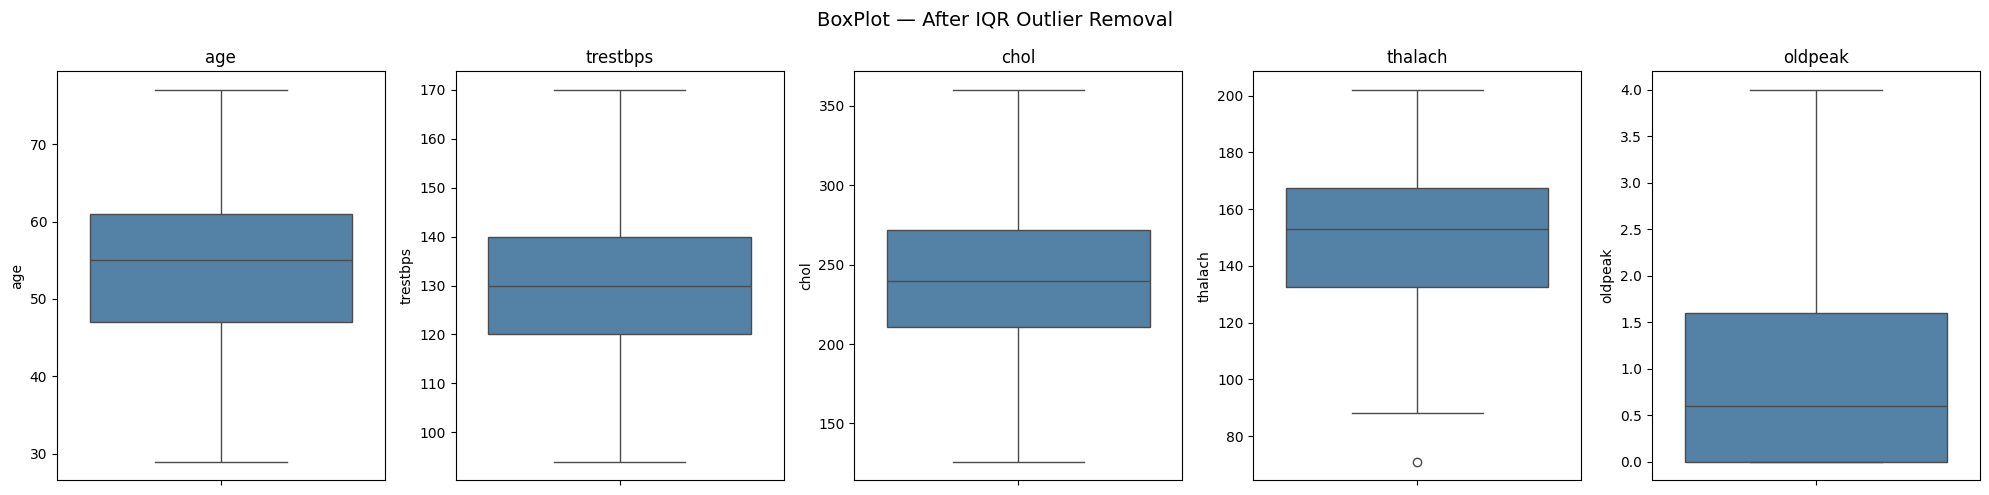

In [76]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df_clean, y=col, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

plt.suptitle("BoxPlot — After IQR Outlier Removal", fontsize=14)
plt.tight_layout()
plt.show()

```
Outliers and Skewness removed

In [77]:
df_clean.shape

(279, 14)

In [78]:
df_clean.dtypes

age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object

In [79]:
# duplicates after outlier removal
print("Duplicates:", df_clean.duplicated().sum())

Duplicates: 0


In [80]:
# class balance after outlier removal
from collections import Counter

print("Target distribution after cleaning:")
print(Counter(df_clean["condition"]))

disease_pct = Counter(df_clean["condition"])[1] / len(df_clean) * 100
print(f"Heart disease: {disease_pct:.1f}%")

Target distribution after cleaning:
Counter({0: 154, 1: 125})
Heart disease: 44.8%


```
1. X Y split                              ← now
2. Train test split (stratify)
3. One Hot Encoding — fit on train, transform on test
4. Multicollinearity — check on X_train only
5. StandardScaler — fit on train, transform on test
6. Model training

___
# X and Y split 
___

In [81]:
X = df_clean.drop("condition", axis=1)
Y = df_clean["condition"]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (279, 13)
Y shape: (279,)


___
# Train Test Split
___

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = Y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

from collections import Counter
print("\ny_train:", Counter(y_train))
print("y_test :", Counter(y_test))

X_train: (223, 13)
X_test : (56, 13)

y_train: Counter({0: 123, 1: 100})
y_test : Counter({0: 31, 1: 25})


```
Train → 55% no disease, 45% disease → fairly balanced
Test  → 55% no disease, 45% disease → stratify worked ✅

___
# Encoding 
___

In [84]:
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [85]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



In [86]:
#
#   ONe Hot Encoder 
    # for that we need indexs of those column
# 
#  nominal categorical columns — no natural order
# cp      → index 2 (chest pain type 0,1,2,3)
# restecg → index 6 (ECG result 0,1,2)
# slope   → index 10 (ST slope 0,1,2)
# thal    → index 12 (thalassemia type 0,1,2)

# confirm column positions before encoding
for i, col in enumerate(X_train.columns):
    print(f"{i}: {col}")

0: age
1: sex
2: cp
3: trestbps
4: chol
5: fbs
6: restecg
7: thalach
8: exang
9: oldpeak
10: slope
11: ca
12: thal


In [87]:
ct = ColumnTransformer(
    transformers=[
        ("OneHot", OneHotEncoder(drop="first", sparse_output=False), [2, 6, 10, 12])
        # cp=2, restecg=6, slope=10, thal=12
    ],
    remainder="passthrough"
)

X_train = ct.fit_transform(X_train)   # fit + transform on train
X_test  = ct.transform(X_test)        # only transform on test — no leakage

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (223, 18)
X_test  shape: (56, 18)


In [88]:
X_train  
# its an array 
# we need to convert it into dataframe 

array([[1. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 1. , 0. , ..., 1. , 0.6, 0. ],
       [1. , 0. , 0. , ..., 0. , 0. , 2. ],
       ...,
       [0. , 0. , 1. , ..., 0. , 0.1, 3. ],
       [0. , 0. , 1. , ..., 0. , 1.2, 2. ],
       [0. , 0. , 1. , ..., 0. , 2. , 2. ]], shape=(223, 18))

In [89]:
# 1st get column names 
ohe_cols  = ct.named_transformers_["OneHot"].get_feature_names_out(["cp", "restecg", "slope", "thal"])
pass_cols = ["age", "sex", "trestbps", "chol", "fbs", "thalach", "exang", "oldpeak", "ca"]

all_cols = list(ohe_cols) + pass_cols

print("Total features:", len(all_cols))

Total features: 18


In [90]:
# converting into DF
X_train = pd.DataFrame(X_train, columns=all_cols)
X_test  = pd.DataFrame(X_test,  columns=all_cols)

X_train.head()

,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,49.0,0.0,134.0,271.0,0.0,162.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,58.0,1.0,105.0,240.0,0.0,154.0,1.0,0.6,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63.0,0.0,140.0,195.0,0.0,179.0,0.0,0.0,2.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,59.0,1.0,126.0,218.0,1.0,134.0,0.0,2.2,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34.0,0.0,118.0,210.0,0.0,192.0,0.0,0.7,0.0


___
# Multi Colinearity 

```
Drop Highly corelated cols
```

___

In [91]:
X_train.corr()

,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca
cp_1,1.000000,-0.297829,-0.435776,-0.045152,-0.060011,-0.199293,-0.068684,-0.054657,-0.214047,-0.141969,-0.078079,-0.078032,0.022533,-0.056870,0.259989,-0.257100,-0.279382,-0.158093
cp_2,-0.297829,1.000000,-0.576126,0.045955,-0.092457,-0.050696,0.013916,-0.096940,-0.163268,-0.070452,-0.112125,-0.043673,-0.048962,0.064552,0.151768,-0.246716,-0.082104,-0.134923
cp_3,-0.435776,-0.576126,1.000000,0.008135,0.103900,0.195346,0.002067,0.081829,0.335974,0.151493,0.116725,0.003743,0.079108,-0.056704,-0.381531,0.452896,0.239029,0.278681
restecg_1,-0.045152,0.045955,0.008135,1.000000,-0.095558,0.104553,-0.023669,-0.021669,0.027054,0.113785,-0.140642,0.020599,-0.097678,-0.038225,-0.108347,0.035000,0.049174,-0.018031
restecg_2,-0.060011,-0.092457,0.103900,-0.095558,1.000000,0.076998,0.094580,0.102519,-0.012711,0.117883,0.080337,0.177237,0.098431,0.063008,-0.058556,0.082880,0.112287,0.097520
slope_1,-0.199293,-0.050696,0.195346,0.104553,0.076998,1.000000,-0.226382,0.167149,0.230661,0.190680,-0.005745,0.055145,-0.043223,-0.053130,-0.429902,0.209973,0.394424,0.227595
slope_2,-0.068684,0.013916,0.002067,-0.023669,0.094580,-0.226382,1.000000,0.031706,0.011064,0.039837,0.044570,0.097469,-0.050165,0.121310,-0.067569,0.071148,0.288061,-0.098359
thal_1,-0.054657,-0.096940,0.081829,-0.021669,0.102519,0.167149,0.031706,1.000000,-0.172039,0.090772,0.109453,0.227210,-0.098347,0.147896,-0.180418,0.061742,0.118720,0.100857
thal_2,-0.214047,-0.163268,0.335974,0.027054,-0.012711,0.230661,0.011064,-0.172039,1.000000,0.091025,0.330032,0.027619,0.045660,-0.033962,-0.244161,0.347424,0.290779,0.201072
age,-0.141969,-0.070452,0.151493,0.113785,0.117883,0.190680,0.039837,0.090772,0.091025,1.000000,-0.082214,0.269095,0.109919,0.136548,-0.458950,0.100112,0.184308,0.385859


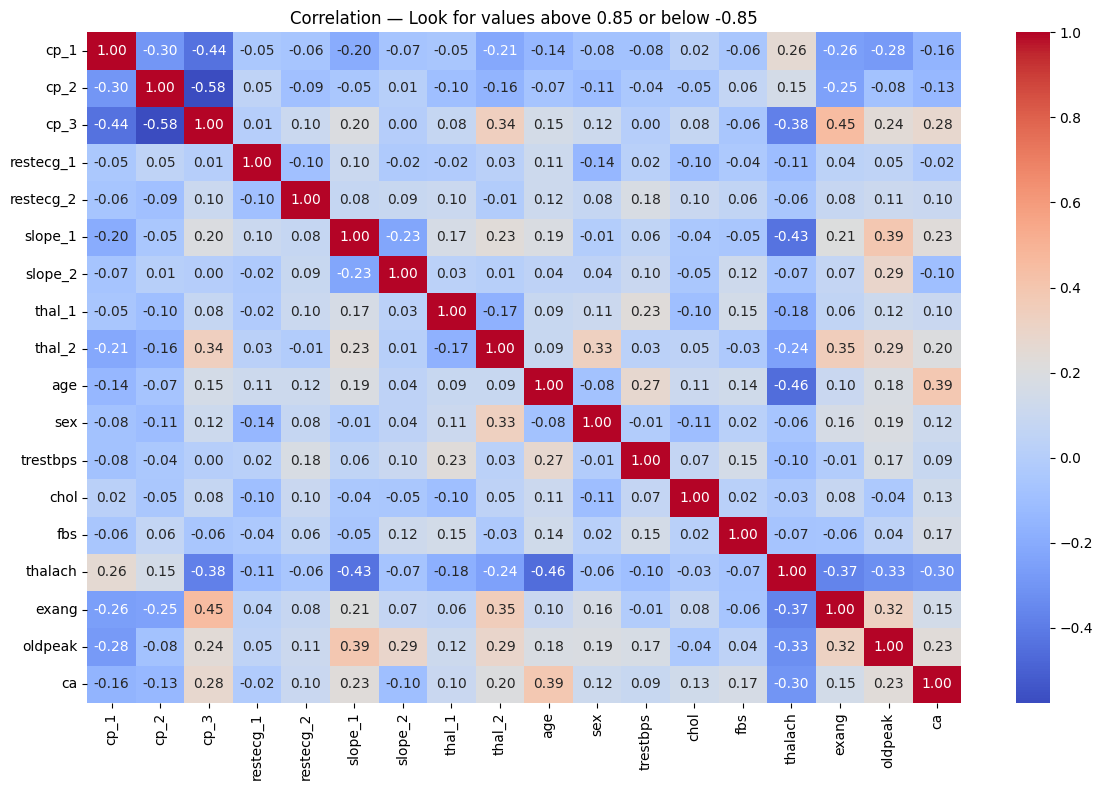

In [92]:
# just plot the heatmap and visually spot dark red/blue pairs

plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation — Look for values above 0.85 or below -0.85")
plt.tight_layout()
plt.show()

# any cell that is dark red (close to 1.0) or dark blue (close to -1.0)
# means those two features are saying the same thing — drop one

In [93]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

corr_features = correlation(X_train, 0.85)
print("Highly correlated features to drop:", corr_features)

Highly correlated features to drop: set()


``` 
no Multi-Colinearit Deteceted as set is empty

```
age    chol   thalach
age       1.00   0.20   -0.90
chol      0.20   1.00    0.15
thalach  -0.90   0.15    1.00


i=0, j=nothing  →  skip (no previous column)
i=1, j=0        →  chol vs age    = 0.20  →  below 0.85  →  skip
i=2, j=0        →  thalach vs age = -0.90 →  above 0.85  →  ADD "thalach" to drop list
i=2, j=1        →  thalach vs chol = 0.15 →  below 0.85  →  skip

___
# Standardziation
____

In [94]:
from sklearn.preprocessing import StandardScaler

In [95]:


scaler = StandardScaler()

# fit_transform on train — learns mean and std from training data
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test — uses SAME mean and std
X_test_scaled  = scaler.transform(X_test)

print("Scaling done")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled  shape:", X_test_scaled.shape)

Scaling done
X_train_scaled shape: (223, 18)
X_test_scaled  shape: (56, 18)


___
# Model Training

```
1. SVC — Linear kernel (baseline)           
2. SVC — RBF kernel                         
3. SVC — Polynomial kernel                  
4. Logistic Regression                      
5. Metrics comparison for all 4             
6. Hyperparameter tuning — best SVC kernel
7. Hyperparameter tuning — Logistic Regression
8. ROC AUC comparison — all models
9. Final model selection
10. Pickle everything
___

In [96]:
from sklearn.svm import SVC

In [97]:
from sklearn.svm import SVC

# linear kernel — simplest SVM
# probability=True needed for ROC AUC later
svc_linear = SVC(kernel="linear", probability=True)

svc_linear.fit(X_train_scaled, y_train)

y_pred_linear = svc_linear.predict(X_test_scaled)

``` 
Differnt Kernel

In [98]:
## Now different kernels one by one 


# RBF — Radial Basis Function — handles non-linear boundaries
# most commonly used kernel in industry
svc_rbf = SVC(kernel="rbf", probability=True)
svc_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svc_rbf.predict(X_test_scaled)


In [99]:
# polynomial kernel — captures curved decision boundaries
svc_poly = SVC(kernel="poly", degree=3, probability=True)
svc_poly.fit(X_train_scaled, y_train)

y_pred_poly = svc_poly.predict(X_test_scaled)

In [100]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

## Metrics of All Above

In [101]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "SVC Linear"    : y_pred_linear,
    "SVC RBF"       : y_pred_rbf,
    "SVC Polynomial": y_pred_poly,
    "Logistic Reg"  : y_pred_lr,
}

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    print(f"{'='*50}")
    print(f"  {name}  →  Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    print()

  SVC Linear  →  Accuracy: 0.8571
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        31
           1       0.95      0.72      0.82        25

    accuracy                           0.86        56
   macro avg       0.88      0.84      0.85        56
weighted avg       0.87      0.86      0.85        56


  SVC RBF  →  Accuracy: 0.8393
              precision    recall  f1-score   support

           0       0.84      0.87      0.86        31
           1       0.83      0.80      0.82        25

    accuracy                           0.84        56
   macro avg       0.84      0.84      0.84        56
weighted avg       0.84      0.84      0.84        56


  SVC Polynomial  →  Accuracy: 0.8214


              precision    recall  f1-score   support

           0       0.77      0.97      0.86        31
           1       0.94      0.64      0.76        25

    accuracy                           0.82        56
   macro avg       0.86      0.80      0.81        56
weighted avg       0.85      0.82      0.81        56


  Logistic Reg  →  Accuracy: 0.8571
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        31
           1       0.95      0.72      0.82        25

    accuracy                           0.86        56
   macro avg       0.88      0.84      0.85        56
weighted avg       0.87      0.86      0.85        56




```
This is heart disease detection

Missing a sick patient (FN) = they go home, no treatment, possible death
False alarm (FP)             = extra test, minor inconvenience

So RECALL for Class 1 is the most important metric here
We want to CATCH every sick person even if we get some false alarms


SVC RBF          →  recall 0.80  ← catches most sick patients ✅
SVC Linear       →  recall 0.72
Logistic Reg     →  recall 0.72
SVC Polynomial   →  recall 0.64  ← misses the most ❌

___
# Hyper Parameter Tuning of SVC RBF
___

In [102]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [103]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# svc_model = SVC(kernel="rbf", probability=True)

# C → regularization strength
# gamma → how far the influence of a single training example reaches
# class_weight → handle any class imbalance

params_svc = {
    "C"            : [0.01, 0.1, 1, 10, 100],
    "gamma"        : ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "class_weight" : ["balanced", None, {0:1, 1:2}, {0:1, 1:3}]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_svc = RandomizedSearchCV(
    estimator           = svc_rbf,
    param_distributions = params_svc,
    n_iter              = 20,
    scoring             = "f1",     # optimize for catching sick patients
    cv                  = cv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

In [104]:
random_svc.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'class_weight': ['balanced', None, ...], 'gamma': ['scale', 'auto', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [105]:
random_svc.best_params_

{'gamma': 0.001, 'class_weight': None, 'C': 100}

In [106]:
random_svc.best_score_

np.float64(0.8019271413396261)

In [107]:
# Perediction

y_pred_svc_tuned = random_svc.predict(X_test_scaled)

print("=" * 50)
print("  SVC RBF — Tuned")
print("=" * 50)
print(f"  Accuracy: {accuracy_score(y_test, y_pred_svc_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_svc_tuned))

  SVC RBF — Tuned
  Accuracy: 0.8571

              precision    recall  f1-score   support

           0       0.81      0.97      0.88        31
           1       0.95      0.72      0.82        25

    accuracy                           0.86        56
   macro avg       0.88      0.84      0.85        56
weighted avg       0.87      0.86      0.85        56



___
# Hyper Parametr Tuning of Logistic Regression 
___

In [108]:
from sklearn.linear_model import LogisticRegression

# lr_model = LogisticRegression(max_iter=1000)

params_lr = {
    "penalty"      : ["l1", "l2"],
    "C"            : [0.01, 0.1, 1, 10, 100],
    "solver"       : ["liblinear", "saga"],
    "class_weight" : ["balanced", None, {0:1, 1:2}, {0:1, 1:3}]
}

random_lr = RandomizedSearchCV(
    estimator           = lr_model,
    param_distributions = params_lr,
    n_iter              = 20,
    scoring             = "recall",
    cv                  = cv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

In [109]:
random_lr.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aizen/AI_ML/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this w

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'class_weight': ['balanced', None, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [110]:
print("Best LR Params  :", random_lr.best_params_)
print("Best CV Recall  :", round(random_lr.best_score_, 4))

Best LR Params  : {'solver': 'saga', 'penalty': 'l2', 'class_weight': {0: 1, 1: 3}, 'C': 0.1}
Best CV Recall  : 0.9


In [111]:
y_pred_lr_tuned = random_lr.predict(X_test_scaled)

print("=" * 50)
print("  Logistic Regression — Tuned")
print("=" * 50)
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_lr_tuned))

  Logistic Regression — Tuned
  Accuracy: 0.8036

              precision    recall  f1-score   support

           0       0.95      0.68      0.79        31
           1       0.71      0.96      0.81        25

    accuracy                           0.80        56
   macro avg       0.83      0.82      0.80        56
weighted avg       0.84      0.80      0.80        56



___
___
# Comparing All the above models 

___
___


In [112]:
# all models — final comparison

all_models = {
    "SVC Linear"       : y_pred_linear,
    "SVC RBF"          : y_pred_rbf,
    "SVC Polynomial"   : y_pred_poly,
    "Logistic Reg"     : y_pred_lr,
    "SVC RBF Tuned"    : y_pred_svc_tuned,
    "LR Tuned"         : y_pred_lr_tuned,
}

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

print(f"{'Model':<20} {'Accuracy':<12} {'Precision(1)':<14} {'Recall(1)':<12} {'F1(1)':<10}")
print("-" * 68)

for name, y_pred in all_models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    print(f"{name:<20} {acc:<12.4f} {prec:<14.4f} {rec:<12.4f} {f1:<10.4f}")

Model                Accuracy     Precision(1)   Recall(1)    F1(1)     
--------------------------------------------------------------------
SVC Linear           0.8571       0.9474         0.7200       0.8182    
SVC RBF              0.8393       0.8333         0.8000       0.8163    
SVC Polynomial       0.8214       0.9412         0.6400       0.7619    
Logistic Reg         0.8571       0.9474         0.7200       0.8182    
SVC RBF Tuned        0.8571       0.9474         0.7200       0.8182    
LR Tuned             0.8036       0.7059         0.9600       0.8136    


___
# ROC Scores for All the Models
___

Model                AUC       
------------------------------
SVC Linear           0.9394    
SVC RBF              0.9110    
SVC Polynomial       0.9316    
Logistic Reg         0.9445    
SVC RBF Tuned        0.9419    
LR Tuned             0.9458    


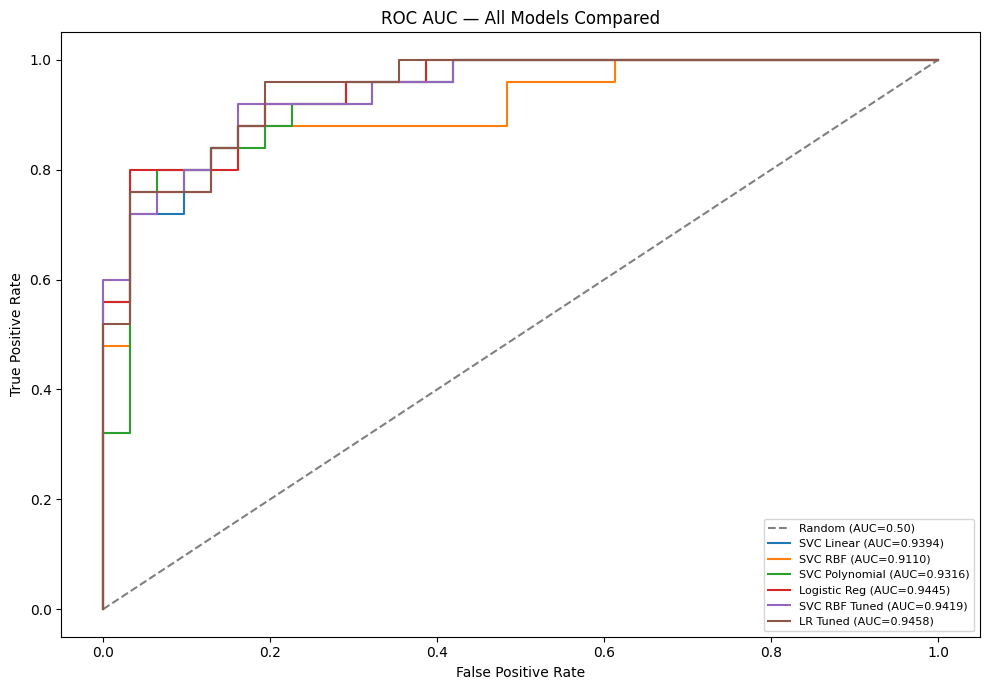

In [114]:
from sklearn.metrics import roc_curve, roc_auc_score

# models that have predict_proba
roc_models = {
    "SVC Linear"     : svc_linear,
    "SVC RBF"        : svc_rbf,
    "SVC Polynomial" : svc_poly,
    "Logistic Reg"   : lr_model,
    "SVC RBF Tuned"  : random_svc,
    "LR Tuned"       : random_lr,
}

fig, ax = plt.subplots(figsize=(10, 7))

# dummy baseline
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC=0.50)")

print(f"{'Model':<20} {'AUC':<10}")
print("-" * 30)

for name, model in roc_models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    auc   = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)

    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
    print(f"{name:<20} {auc:<10.4f}")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC AUC — All Models Compared")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

___
```
For heart disease detection the priority is :
1st → Recall   (catch every sick patient)
2nd → AUC      (overall separation quality)
3rd → Accuracy (least important here)

LR Tuned wins on both :
→ Recall  0.96  →  catches 24 out of 25 sick patients (misses only 1)
→ AUC     0.9458 → highest overall separation
→ Accuracy 0.80  → lower but acceptable trade-off

SVC RBF Tuned has higher accuracy (0.86) but only catches
18 out of 25 sick patients — 7 people go home with undetected heart disease
___

____
____
____

``` 
to check if I model is fiited or not 

    I did this because I was getting Error in above cell, where I was putting random_svc name wrong but I was sure that it correct ( and the graph wasnt appearing ) so to check if ebery model is trained or not I execute the below 

In [116]:
from sklearn.utils.validation import check_is_fitted

roc_models = {
    "SVC Linear"     : svc_linear,
    "SVC RBF"        : svc_rbf,
    "SVC Polynomial" : svc_poly,
    "Logistic Reg"   : lr_model,
    "SVC RBF Tuned"  : random_svc,
    "LR Tuned"       : random_lr,
}

for name, model in roc_models.items():
    print(f"Checking {name}...")

    try:
        check_is_fitted(model)
        print("✅ Fitted")
    except Exception as e:
        print("❌ Not fitted")
        print(e)

Checking SVC Linear...
✅ Fitted
Checking SVC RBF...
✅ Fitted
Checking SVC Polynomial...
✅ Fitted
Checking Logistic Reg...
✅ Fitted
Checking SVC RBF Tuned...
✅ Fitted
Checking LR Tuned...
✅ Fitted


___
___
# Checking Differnt Threholds 
___
___


In [117]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [118]:

# get probabilities from best model (LR Tuned)
model_probs = random_lr.predict_proba(X_test_scaled)[:, 1]

# try different thresholds
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print(f"{'Threshold':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<10}")
print("-" * 58)

for t in thresholds:
    y_pred_t = (model_probs >= t).astype(int)
    acc  = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec  = recall_score(y_test, y_pred_t)
    f1   = f1_score(y_test, y_pred_t)
    
    # mark the sweet spot — high recall without destroying precision
    flag = " ← " if rec >= 0.90 and prec >= 0.50 else ""
    print(f"{t:<12} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<10.4f}{flag}")

Threshold    Accuracy     Precision    Recall       F1        
----------------------------------------------------------
0.2          0.6964       0.5952       1.0000       0.7463     ← 
0.25         0.7321       0.6250       1.0000       0.7692     ← 
0.3          0.7500       0.6410       1.0000       0.7812     ← 
0.35         0.7679       0.6579       1.0000       0.7937     ← 
0.4          0.8036       0.6944       1.0000       0.8197     ← 
0.45         0.7857       0.6857       0.9600       0.8000     ← 
0.5          0.8036       0.7059       0.9600       0.8136     ← 
0.55         0.8393       0.7500       0.9600       0.8421     ← 
0.6          0.8393       0.7857       0.8800       0.8302    


```
0.55 gives best result 

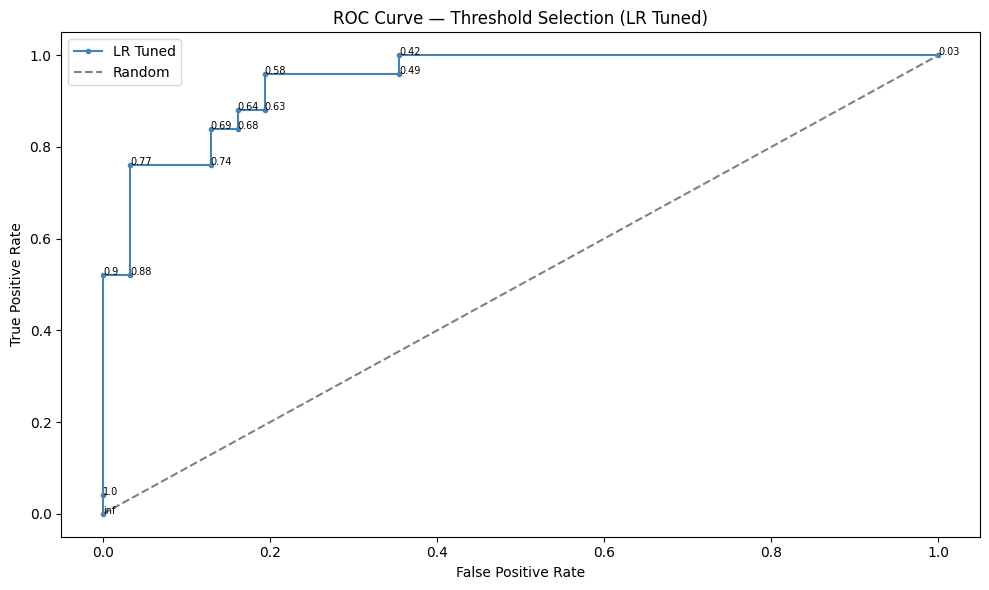

In [119]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, threshold = roc_curve(y_test, model_probs)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(fpr, tpr, marker='.', color="steelblue", label="LR Tuned")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")

# annotate thresholds on the curve
for xyz in zip(fpr, tpr, threshold):
    ax.annotate('%s' % np.round(xyz[2], 2), xy=(xyz[0], xyz[1]), fontsize=7)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Threshold Selection (LR Tuned)")
ax.legend()

plt.tight_layout()
plt.show()

# find where FPR is low and TPR is high
# that annotated number is your best threshold

In [120]:
# Youden's J statistic — industry standard for optimal threshold
# J = TPR - FPR → highest J = best balance between catching disease and avoiding false alarms

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold = threshold[best_idx]
best_tpr       = tpr[best_idx]
best_fpr       = fpr[best_idx]

print(f"Best threshold (Youden's J) : {best_threshold:.4f}")
print(f"At this threshold :")
print(f"  TPR (Recall)  : {best_tpr:.4f}  ← catches {best_tpr*100:.0f}% of sick patients")
print(f"  FPR           : {best_fpr:.4f}  ← falsely flags {best_fpr*100:.0f}% of healthy")
print(f"  Youden's J    : {j_scores[best_idx]:.4f}")

Best threshold (Youden's J) : 0.5805
At this threshold :
  TPR (Recall)  : 0.9600  ← catches 96% of sick patients
  FPR           : 0.1935  ← falsely flags 19% of healthy
  Youden's J    : 0.7665


```
Threshold 0.55 :
  Recall    = 0.96   →  misses only 1 sick patient
  Precision = 0.75   →  3 out of 4 flagged patients actually have disease
  Accuracy  = 0.84
  F1        = 0.84

In [121]:
best_threshold = 0.55

y_pred_final = (model_probs >= best_threshold).astype(int)

print(f"{'='*50}")
print(f"  FINAL MODEL — LR Tuned + Threshold {best_threshold}")
print(f"{'='*50}")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print()
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print(f"Disease caught  : {tp} / {tp+fn}  ({tp/(tp+fn)*100:.1f}%)")
print(f"Disease missed  : {fn} / {tp+fn}  ({fn/(tp+fn)*100:.1f}%)")
print(f"False alarms    : {fp} / {tn+fp}  ({fp/(tn+fp)*100:.1f}%)")

  FINAL MODEL — LR Tuned + Threshold 0.55
  Accuracy: 0.8393

              precision    recall  f1-score   support

           0       0.96      0.74      0.84        31
           1       0.75      0.96      0.84        25

    accuracy                           0.84        56
   macro avg       0.85      0.85      0.84        56
weighted avg       0.87      0.84      0.84        56

Disease caught  : 24 / 25  (96.0%)
Disease missed  : 1 / 25  (4.0%)
False alarms    : 8 / 31  (25.8%)


____
# pickling the Models 
____

In [122]:
import pickle 
import os

In [123]:
os.makedirs("models", exist_ok=True)

In [124]:

# ---- Save all models ----
with open("models/svc_linear.pkl", "wb") as f:
    pickle.dump(svc_linear, f)

print("✅ SVC Linear saved")


with open("models/svc_rbf.pkl", "wb") as f:
    pickle.dump(svc_rbf, f)

print("✅ SVC RBF saved")


with open("models/svc_poly.pkl", "wb") as f:
    pickle.dump(svc_poly, f)

print("✅ SVC Polynomial saved")


with open("models/lr_basic.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("✅ Logistic Regression saved")


with open("models/svc_rbf_tuned.pkl", "wb") as f:
    pickle.dump(random_svc, f)

print("✅ SVC RBF Tuned saved")


with open("models/lr_tuned.pkl", "wb") as f:
    pickle.dump(random_lr, f)

print("✅ LR Tuned saved — BEST MODEL")


# ---- Save scaler ----
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Scaler saved")

# ---- Save column transformer ----
with open("models/column_transformer.pkl", "wb") as f:
    pickle.dump(ct, f)

print("✅ ColumnTransformer saved")


# ---- Save feature columns ----
with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(all_cols, f)

print("✅ Feature columns saved")

# ---- Save threshold ----
with open("models/threshold.pkl", "wb") as f:
    pickle.dump(0.55, f)
    
print("✅ Threshold saved (0.55)")

✅ SVC Linear saved
✅ SVC RBF saved
✅ SVC Polynomial saved
✅ Logistic Regression saved
✅ SVC RBF Tuned saved
✅ LR Tuned saved — BEST MODEL
✅ Scaler saved
✅ ColumnTransformer saved
✅ Feature columns saved
✅ Threshold saved (0.55)
